# 05_modelos_regularizados
Notebook para entrenar y comparar Ridge, Lasso y ElasticNet.

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

## Cargar dataset limpio

In [11]:
df = pd.read_parquet("data/listings_clean.parquet")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city,log_price
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas",4.584967
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas",5.081404
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas",3.663562
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas",4.983607
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas",4.077537


## Seleccionar variables

In [12]:
features = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "estimated_occupancy_l365d"
]

target = "log_price"

data_model = df[features + [target]].dropna()

X = data_model[features]
y = data_model[target]

print(X.shape)
X.head()

(76032, 5)


,accommodates,bathrooms,bedrooms,beds,estimated_occupancy_l365d
0,3,1.0,1.0,2.0,150
1,2,1.0,1.0,2.0,84
2,2,1.0,1.0,1.0,8
3,3,2.0,2.0,2.0,30
4,2,1.0,1.0,1.0,180


In [13]:
X.dtypes

accommodates                   int32
bathrooms                    float64
bedrooms                     float64
beds                         float64
estimated_occupancy_l365d      int32
dtype: object

## Train / Test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(60825, 5) (15207, 5)


## Escalar variables

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Entrenar modelos

In [16]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)
elastic_pred = elastic.predict(X_test_scaled)

## Evaluación de modelos

In [17]:
def evaluar(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

ridge_rmse, ridge_r2 = evaluar(y_test, ridge_pred)
lasso_rmse, lasso_r2 = evaluar(y_test, lasso_pred)
elastic_rmse, elastic_r2 = evaluar(y_test, elastic_pred)

resultados = pd.DataFrame({
    "Modelo": ["Ridge", "Lasso", "ElasticNet"],
    "RMSE": [ridge_rmse, lasso_rmse, elastic_rmse],
    "R2": [ridge_r2, lasso_r2, elastic_r2]
})

resultados

,Modelo,RMSE,R2
0,Ridge,0.818603,0.321671
1,Lasso,0.818850,0.321262
2,ElasticNet,0.818403,0.322002


## Comparación gráfica

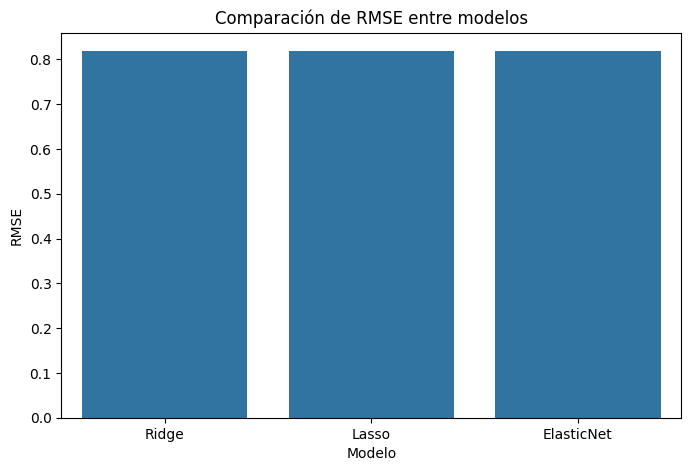

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(data=resultados, x="Modelo", y="RMSE")
plt.title("Comparación de RMSE entre modelos")
plt.show()